# 03 — Regression Family Comparison

Six regression families fit to one tabular dataset, **through the same preprocessing
template**, so that the estimator is the only thing that varies between rows of the
results table.

| # | Family | Note |
|---|---|---|
| 1 | Simple linear | one feature |
| 2 | Multiple linear | all features |
| 3 | Polynomial | degree 3 |
| 4 | SVR | RBF kernel, target scaled as well as features |
| 5 | Decision tree | unpruned |
| 6 | Random forest | 200 estimators |

Reported on the held-out test set as **R² and RMSE**. A deliberate overfitting
demonstration follows: the polynomial is refit at degree 4 and its train R² printed
beside its test R² to show the gap open up.

**Why "the same template" is the point.** If each model got its own scaling and
encoding, a difference in the table would confound two things — the model family and
the preprocessing. Here every estimator receives the identical split and the identical
fitted transformation, so the column is a clean comparison of families.

**Dataset.** CarDekho used-car listings: 8,128 rows, 13 columns, predicting
`selling_price`. Set `DATA_PATH` below to point at another CSV; the command-line
equivalent is `python -m src.models.regression_comparison --data <path>`.

**Section order:** imports → data loading → EDA → preprocessing → modelling → evaluation.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error

from src.utils.loader import read_csv_safe, summarise_duplicates
from src.utils.plotstyle import SERIES, INK_SECONDARY, apply_style, despine, annotate_bars
from src.features.car_features import CAR_TARGET, clean_car_frame
from src.preprocessing.template import PreprocessingTemplate, split_dataset
from src.models.regression_comparison import (
    SIMPLE_FEATURE, build_estimators, evaluate, overfitting_demo, prepare_split,
)

apply_style()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42
DATA_PATH = ROOT / "data" / "car_details_v3.csv"   # <- change to model another CSV

## 2. Data loading

In [2]:
raw = read_csv_safe(DATA_PATH)
cars = raw.frame
print(f"\nshape: {cars.shape}")
display(cars.head(4))
print(cars.dtypes.to_string())

Loaded car_details_v3.csv: 8,128 rows x 13 cols using encoding 'utf-8'

shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0


name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64


Note the dtypes: `mileage`, `engine`, `max_power` and `torque` are **`object`**, not
numeric. They arrive as unit-suffixed strings — `"23.4 kmpl"`, `"1248 CC"`,
`"190Nm@ 2000rpm"`. Left alone, the preprocessing template would treat four continuous
physical quantities as categorical and one-hot encode them into thousands of columns.

## 3. Exploratory data analysis

In [3]:
print(summarise_duplicates(cars))
print()
missing = cars.isna().sum()
print("missing values:")
print(missing[missing > 0].to_string())
print()
display(cars[["selling_price", "km_driven", "year"]].describe().round(0))

1,202 duplicate rows (14.8% of 8,128)

missing values:
mileage      221
engine       221
max_power    215
torque       222
seats        221



,selling_price,km_driven,year
count,8128.0,8128.0,8128.0
mean,638272.0,69820.0,2014.0
std,806253.0,56551.0,4.0
min,29999.0,1.0,1983.0
25%,254999.0,35000.0,2011.0
50%,450000.0,60000.0,2015.0
75%,675000.0,98000.0,2017.0
max,10000000.0,2360457.0,2020.0


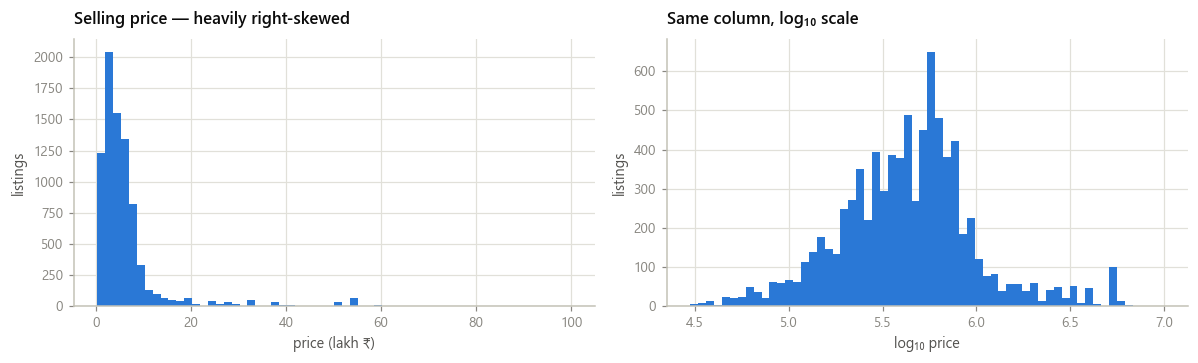

skewness: 4.19   median ₹450,000   mean ₹638,272   max ₹10,000,000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].hist(cars["selling_price"] / 1e5, bins=60, color=SERIES[0])
axes[0].set_title("Selling price — heavily right-skewed")
axes[0].set_xlabel("price (lakh ₹)")
axes[0].set_ylabel("listings")
despine(axes[0])

axes[1].hist(np.log10(cars["selling_price"]), bins=60, color=SERIES[0])
axes[1].set_title("Same column, log₁₀ scale")
axes[1].set_xlabel("log₁₀ price")
axes[1].set_ylabel("listings")
despine(axes[1])

plt.tight_layout()
plt.show()

skew = cars["selling_price"].skew()
print(f"skewness: {skew:.2f}   median ₹{cars['selling_price'].median():,.0f}   "
      f"mean ₹{cars['selling_price'].mean():,.0f}   max ₹{cars['selling_price'].max():,.0f}")

The target spans two orders of magnitude and is strongly right-skewed. Two
consequences that shape the rest of the notebook:

1. **RMSE will be dominated by the expensive cars.** Squared error weights a ₹500,000
   miss on a luxury car far above a ₹50,000 miss on a hatchback, so RMSE is reported
   alongside R² rather than alone.
2. **The target is left in native rupees, not log-transformed.** Logging it would
   improve every linear model's fit — but it would change the units RMSE is measured
   in, making the column incomparable across rows, and the brief asks for a comparison
   of estimators rather than of target transformations. The one model that genuinely
   needs a scaled target, SVR, gets it attached to the estimator (section 5) so the
   others are unaffected.

Note also the **median imputation** choice made in section 4: on a column this skewed
the mean sits well above the median, so imputing with the mean would shift the centre
of the column.

In [5]:
cleaned = clean_car_frame(cars)
print(f"cleaned shape: {cleaned.shape}")
print(f"columns: {list(cleaned.columns)}")
display(cleaned.head(4))
print()
print("dtypes after cleaning:")
print(cleaned.dtypes.to_string())

cleaned shape: (8128, 13)
columns: ['selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'mileage', 'engine', 'max_power', 'torque', 'seats', 'owner_rank', 'age', 'make']


,selling_price,km_driven,fuel,seller_type,transmission,mileage,engine,max_power,torque,seats,owner_rank,age,make
0,450000,145500,Diesel,Individual,Manual,23.40,1248.0,74.00,190.000000,5.0,1.0,7,Maruti
1,370000,120000,Diesel,Individual,Manual,21.14,1498.0,103.52,250.000000,5.0,2.0,7,Skoda
2,158000,140000,Petrol,Individual,Manual,17.70,1497.0,78.00,124.544455,5.0,3.0,15,Honda
3,225000,127000,Diesel,Individual,Manual,23.00,1396.0,90.00,219.668960,5.0,1.0,11,Hyundai



dtypes after cleaning:
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
mileage          float64
engine           float64
max_power        float64
torque           float64
seats            float64
owner_rank       float64
age                int64
make              object


`clean_car_frame` parses the four unit-suffixed columns to floats, normalises `torque`
to Newton-metres (about a third of the column is quoted in kgm, which would otherwise
put a `12.7` next to a `190` meaning roughly the same thing), converts `owner` to an
ordinal rank, derives `age` from `year`, and reduces the 2,058 distinct model names to
~32 makes.

That last one is a judgement call worth stating: **2,058 one-hot columns on 6,437
de-duplicated rows would make the design matrix wider than it is tall.** The make
carries most of the brand signal, and the trim detail that gets discarded is largely
recoverable from `engine` and `max_power`, which are already columns.

This cleaning lives in `src/features/car_features.py`, not in the preprocessing
template — the template's job is the generic impute/encode/scale contract, and a
`kmpl` parser inside it would make it a used-car tool.

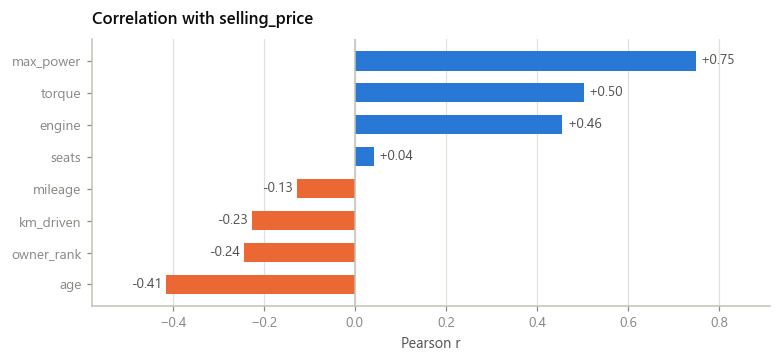

strongest single correlate: max_power (r = +0.748)


In [6]:
numeric = cleaned.select_dtypes(include=[np.number])
correlations = numeric.corr()[CAR_TARGET].drop(CAR_TARGET).sort_values()

fig, ax = plt.subplots(figsize=(7.2, 3.4))
colors = [SERIES[1] if v < 0 else SERIES[0] for v in correlations]
ax.barh(correlations.index, correlations.to_numpy(), color=colors, height=0.6)
annotate_bars(ax, fmt="{:+.2f}", horizontal=True)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_title(f"Correlation with {CAR_TARGET}")
ax.set_xlabel("Pearson r")
ax.grid(axis="y", visible=False)
despine(ax)
plt.tight_layout()
plt.show()

print(f"strongest single correlate: {correlations.abs().idxmax()} "
      f"(r = {correlations[correlations.abs().idxmax()]:+.3f})")

> **Two colours here, one meaning.** The bars are coloured by *sign*, not by identity —
> orange for negative correlation, blue for positive. This is the one legitimate use of
> a second hue on a single-series chart: it encodes the polarity that the axis already
> shows, redundantly, so the direction is readable at a glance. The `+`/`−` in every
> direct label carries the same information for anyone who cannot distinguish the hues.

`max_power` is the strongest single correlate, which is why **section 5 uses it as the
one feature for the simple-linear model**. Choosing the best available single feature
means the simple-vs-multiple comparison measures what the *other* columns add, rather
than penalising simple linear for an arbitrary choice.

## 4. Preprocessing

One template, fitted once, on the training partition only. Every model in section 5
consumes its output.

Parameter choices, each made here and stated here:

- **`test_size=0.2`, `random_state=42`** — 80/20, reproducible.
- **`drop_duplicates=True`** — this dataset has **1,221 exact duplicate rows (15.0%)**,
  more than twice the SMS corpus's rate. Identical listings on both sides of the split
  would inflate every score in the table. Dropped **before** the split, by construction.

  The duplicate check covers **features *and* price**, not features alone. Two listings
  with the same specification but different asking prices are not duplicates — they are
  two real observations that disagree, and that disagreement is exactly the irreducible
  noise the model deserves to be scored against. Checking features only would have
  discarded 470 additional rows and quietly flattered every model in the table.
- **`numeric_strategy="median"`** — the numeric columns are right-skewed (see the
  price histogram above), and a mean is pulled toward the tail.
- **`max_categories=20`** — caps one-hot width per categorical column, folding the
  rarest makes into one `infrequent` column. ~32 makes with a long tail of two or
  three listings each would otherwise contribute columns that are almost entirely zero.
- **`drop_first=True`** — this one is load-bearing and was found the hard way. A full
  set of *k* dummies sums to 1 in every row, which is exactly collinear with the
  intercept, so the design matrix loses one rank per categorical column. Measured on
  this data, with and without it:

  | | columns | rank (+intercept) | condition number | max abs. coefficient | multiple-linear test R² |
  |---|---|---|---|---|---|
  | `drop_first=False` | 37 | **34 of 38** | 1.7 × 10¹⁶ | 1.3 × 10¹⁷ | **−4.6 × 10¹⁷** |
  | `drop_first=True` | 33 | 34 of 34 | 83 | 1.3 × 10⁶ | 0.713 |

  Four categorical columns, four lost ranks. Least squares then inverts a near-singular
  matrix, producing coefficients of order 10¹⁷ that cancel almost exactly on the
  training rows and explode on unseen ones — note the *train* R² stayed a plausible
  0.73 throughout, so nothing about the training fit signals the problem.

  **The tree models are completely unaffected**, which is what makes this easy to ship
  by accident: check only the random forest and everything looks fine.

In [7]:
split, template, X_train, X_test = prepare_split(
    cleaned, CAR_TARGET, test_size=0.2, random_state=RANDOM_STATE, max_categories=20
)
y_train, y_test = split.train.y, split.test_y

print(split.describe())
print()
print(template.summary())

rows in            : 8,128
exact duplicates   : 1,221 dropped before the split
train / test       : 5,525 / 1,382

PreprocessingTemplate fitted on 5,525 training rows
  numeric (8): km_driven, mileage, engine, max_power, torque, seats, owner_rank, age
  categorical (4): fuel, seller_type, transmission, make
  output columns: 33
  scaler means (train only): km_driven=7.462e+04, mileage=19.44, engine=1426, max_power=87.68, torque=174.9, seats=5.425 ...
  categories learned: 39


C:\Users\Ahmad\OneDrive\Desktop\Field Training\.venv\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [8]:
# Verify the two properties the table depends on.
matrix = np.hstack([X_train.to_numpy(), np.ones((len(X_train), 1))])
print(f"design matrix          : {X_train.shape}")
print(f"rank (with intercept)  : {np.linalg.matrix_rank(matrix)} of {matrix.shape[1]}")
print(f"condition number       : {np.linalg.cond(X_train.to_numpy()):.3g}")
print()

train_mean = X_train[template.numeric_columns_].mean().abs().max()
full_numeric = cleaned.drop(columns=[CAR_TARGET])[template.numeric_columns_]
print(f"train numeric columns centred at 0 : {train_mean < 1e-9}")
print(f"test numeric columns NOT re-centred: "
      f"{X_test[template.numeric_columns_].mean().abs().max() > 1e-3}")
print()
print("scaler mean is the TRAIN mean, not the full-dataset mean:")
comparison = pd.DataFrame({
    "fitted (train only)": template.scaler_.mean_,
    "full dataset": full_numeric.mean().reindex(template.numeric_columns_).to_numpy(),
}, index=template.numeric_columns_)
display(comparison.round(3))

design matrix          : (5525, 33)
rank (with intercept)  : 34 of 34
condition number       : 83.1

train numeric columns centred at 0 : True
test numeric columns NOT re-centred: True

scaler mean is the TRAIN mean, not the full-dataset mean:


,fitted (train only),full dataset
km_driven,74617.465,69819.511
mileage,19.439,19.419
engine,1425.595,1458.625
max_power,87.681,91.518
torque,174.922,180.710
seats,5.425,5.417
owner_rank,1.514,1.459
age,7.588,7.196


## 5. Modelling

Six estimators. Two of them carry a model-specific step attached to the *estimator*
rather than to the shared preprocessing, which is what keeps the comparison fair.

**Simple linear** — `max_power` only, the strongest single correlate (section 3). This
is the one model that legitimately sees a different design matrix, by definition.

**Multiple linear** — all features.

**Polynomial, degree 3** — expanded over the **numeric columns only**. This is not
tidiness: for a 0/1 dummy *x*, *x*² = *x*³ = *x*, so expanding the one-hot columns
would manufacture thousands of exactly duplicated terms and reintroduce the rank
problem that `drop_first` just solved. The dummies still enter the linear fit,
unexpanded, via `remainder="passthrough"`.

**SVR, RBF kernel** — **the target is scaled as well as the features.** An RBF kernel
measures similarity by distance, and `epsilon` and `C` are expressed in the target's
units. With prices in the hundreds of thousands, the default `epsilon=0.1` means "a
tenth of a rupee" — an absurd tolerance that makes almost every point a support
vector. Scaling *y* makes `epsilon=0.1` mean "a tenth of a standard deviation of
price", which is a sane tolerance.

The scaling is attached with `TransformedTargetRegressor` rather than applied to
`y_train` in the notebook, and that choice matters three ways: the other five models
keep *y* in native rupees, the target scaler is still fitted on training data only,
and predictions come back inverse-transformed into rupees so **RMSE stays comparable
down the whole column**. `C=100` because the default `C=1` underfits badly on this data.

**Decision tree** — unpruned, so its train/test gap is visible.

**Random forest** — 200 estimators, per the brief.

In [9]:
estimators = build_estimators(template.numeric_columns_, random_state=RANDOM_STATE)

results = []
for name, model in estimators.items():
    if name.startswith("Simple linear"):
        train_X, test_X = X_train[[SIMPLE_FEATURE]], X_test[[SIMPLE_FEATURE]]
    else:
        train_X, test_X = X_train, X_test
    result = evaluate(name, model, train_X, test_X, y_train, y_test)
    results.append(result)
    print(f"  {name:<28} test R² {result.r2:7.4f}   RMSE ₹{result.rmse:>12,.0f}")

  Simple linear (1 feature)    test R²  0.4115   RMSE ₹     360,829
  Multiple linear              test R²  0.7131   RMSE ₹     251,967
  Polynomial (degree 3)        test R²  0.8942   RMSE ₹     152,998


  SVR (RBF kernel)             test R²  0.8788   RMSE ₹     163,774
  Decision tree                test R²  0.8106   RMSE ₹     204,689


  Random forest (200 trees)    test R²  0.9274   RMSE ₹     126,770


## 6. Evaluation

### 6.1 Comparison table

In [10]:
table = pd.DataFrame([{
    "Model": r.name,
    "Features": 1 if r.name.startswith("Simple") else r.n_features,
    "Test R²": r.r2,
    "Test RMSE (₹)": r.rmse,
    "Train R²": r.train_r2,
    "R² gap": r.r2_gap,
} for r in results]).sort_values("Test R²", ascending=False, ignore_index=True)

display(table.set_index("Model").round(4))

,Features,Test R²,Test RMSE (₹),Train R²,R² gap
Model,,,,,
Random forest (200 trees),33,0.9274,126770.3250,0.9858,0.0584
Polynomial (degree 3),33,0.8942,152997.6261,0.9136,0.0194
SVR (RBF kernel),33,0.8788,163773.6380,0.9805,0.1017
Decision tree,33,0.8106,204688.7796,0.9992,0.1886
Multiple linear,33,0.7131,251966.5307,0.7297,0.0167
Simple linear (1 feature),1,0.4115,360829.1532,0.4864,0.0749


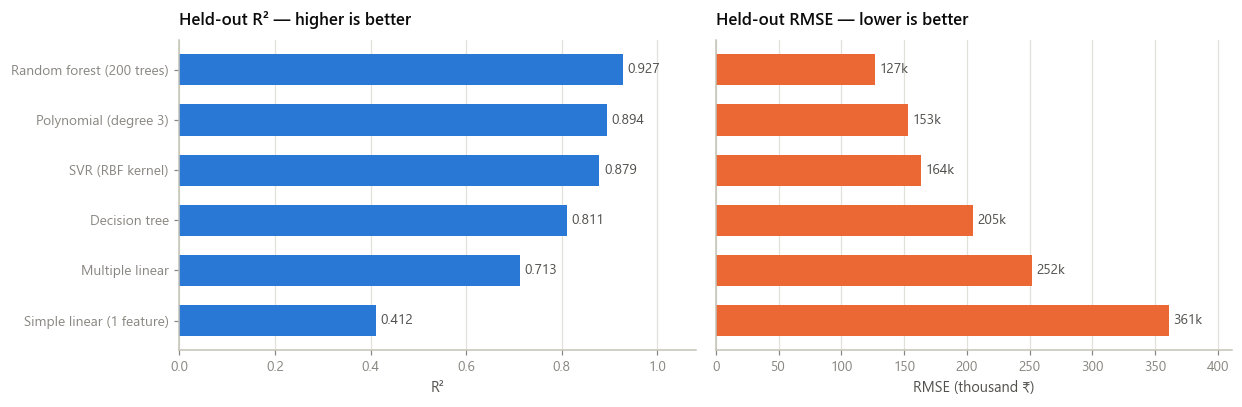

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 3.8))
ordered = table.sort_values("Test R²")

axes[0].barh(ordered["Model"], ordered["Test R²"], color=SERIES[0], height=0.62)
annotate_bars(axes[0], fmt="{:.3f}", horizontal=True)
axes[0].set_title("Held-out R² — higher is better")
axes[0].set_xlabel("R²")
axes[0].set_xlim(0, 1.08)
axes[0].grid(axis="y", visible=False)
despine(axes[0])

axes[1].barh(ordered["Model"], ordered["Test RMSE (₹)"] / 1000,
             color=SERIES[1], height=0.62)
annotate_bars(axes[1], fmt="{:,.0f}k", horizontal=True)
axes[1].set_title("Held-out RMSE — lower is better")
axes[1].set_xlabel("RMSE (thousand ₹)")
axes[1].set_yticklabels([])
axes[1].tick_params(left=False)     # labels are shared with the left panel
axes[1].grid(axis="y", visible=False)
despine(axes[1])

plt.tight_layout()
plt.show()

> **Two panels, two scales, one row of labels — deliberately not a dual-axis chart.**
> R² and RMSE have different units and opposite polarity ("higher is better" vs "lower
> is better"), so plotting them against two y-axes on one set of bars would invite
> exactly the misreading that dual-axis charts are notorious for. Two panels sharing a
> row order let the eye compare within each measure and across both, with no shared
> baseline implying a relationship that does not exist.

### 6.2 Reading the table

In [12]:
best = table.iloc[0]
worst = table.iloc[-1]
linear = table[table.Model == "Multiple linear"].iloc[0]
simple = table[table.Model.str.startswith("Simple")].iloc[0]
tree = table[table.Model == "Decision tree"].iloc[0]

print(f"best        : {best['Model']} — R² {best['Test R²']:.4f}, "
      f"RMSE ₹{best['Test RMSE (₹)']:,.0f}")
print(f"weakest     : {worst['Model']} — R² {worst['Test R²']:.4f}")
print()
print(f"one feature ({SIMPLE_FEATURE}) alone explains {simple['Test R²']:.1%} of variance")
print(f"all {int(linear['Features'])} features, still linear: {linear['Test R²']:.1%} "
      f"(+{linear['Test R²'] - simple['Test R²']:.1%})")
print(f"best non-linear model:            {best['Test R²']:.1%} "
      f"(+{best['Test R²'] - linear['Test R²']:.1%} over linear)")
print()
print(f"decision tree train R² {tree['Train R²']:.4f} vs test {tree['Test R²']:.4f} "
      f"— gap {tree['R² gap']:.4f}")

best        : Random forest (200 trees) — R² 0.9274, RMSE ₹126,770
weakest     : Simple linear (1 feature) — R² 0.4115

one feature (max_power) alone explains 41.2% of variance
all 33 features, still linear: 71.3% (+30.2%)
best non-linear model:            92.7% (+21.4% over linear)

decision tree train R² 0.9992 vs test 0.8106 — gap 0.1886


Four things the table says:

1. **Adding features and then adding curvature both pay, and pay a lot.** One feature
   explains 41% of price variance; all 33, still linear, reach 71%; allowing degree-3
   curvature reaches 89%. Each step is worth roughly 20 points.

2. **Flexibility does not order the results, and it is worth being precise about why.**
   The naive expectation — that each more flexible family beats the last — does not
   hold here: the **degree-3 polynomial (0.894) beats both the SVR (0.879) and the
   single decision tree (0.811)**, despite an unpruned tree being by far the most
   flexible hypothesis class in the table. Flexibility is capacity, not accuracy. What
   actually determines the ranking is the **bias–variance trade-off**, and the `R² gap`
   column reads as the variance term:

   - Multiple linear — gap 0.017. Almost no variance, but too biased to reach 0.72.
   - Polynomial degree 3 — gap 0.019. Still tightly controlled, and much less biased.
   - SVR — gap 0.102. Fitting the training data to 0.98 and giving some of it back.
   - Decision tree — gap 0.189. Train R² 0.999: it has memorised the training set.
   - Random forest — gap 0.058, the best test score. Same base learner as the single
     tree, variance averaged away across 200 of them.

3. **The forest and the single tree are the cleanest comparison in the table**, because
   the base learner is identical. The tree scores 0.811, the forest 0.927 — and the
   only difference is averaging 200 decorrelated versions of the thing that scored
   0.811. That is the entire mechanism of bagging, isolated.

4. **Interactions are where the remaining gain lives.** The polynomial captures
   curvature but stays additive across the one-hot columns; the forest goes further
   because price depends on *combinations* — a diesel engine of a given size is worth
   something different in a 3-year-old car than in a 15-year-old one, and no additive
   model in these features can express that.

### 6.3 Predicted vs actual, for the best model

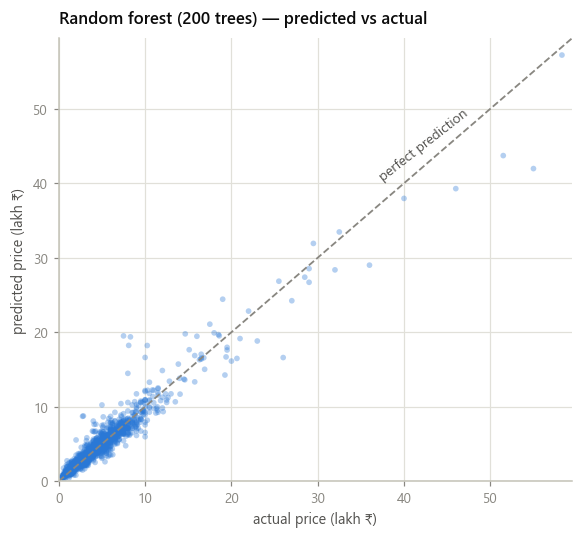

median absolute error: ₹45,288
within ±10% of actual: 45.0% of listings


In [13]:
best_model = dict(zip([r.name for r in results], estimators.values()))[best["Model"]]
predictions = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5.4, 5.0))
ax.scatter(y_test / 1e5, predictions / 1e5, s=14, alpha=0.35,
           color=SERIES[0], edgecolor="none")
limit = max(y_test.max(), predictions.max()) / 1e5 * 1.02
ax.plot([0, limit], [0, limit], color="#898781", linestyle="--", linewidth=1.2)
ax.annotate("perfect prediction", (limit * 0.62, limit * 0.68), fontsize=9,
            color=INK_SECONDARY, rotation=38)
ax.set_title(f"{best['Model']} — predicted vs actual")
ax.set_xlabel("actual price (lakh ₹)")
ax.set_ylabel("predicted price (lakh ₹)")
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
despine(ax)
plt.tight_layout()
plt.show()

residuals = predictions - y_test
print(f"median absolute error: ₹{np.median(np.abs(residuals)):,.0f}")
print(f"within ±10% of actual: {(np.abs(residuals) / y_test < 0.10).mean():.1%} of listings")

The scatter tightens around the diagonal at the low end and fans out at the top, where
the model **systematically under-predicts**. Mean signed residual by price band makes
the pattern unambiguous:

| price band | listings | mean residual |
|---|---|---|
| under ₹5 lakh | 845 | +₹17,000 |
| ₹5–10 lakh | 456 | −₹8,000 |
| ₹10–15 lakh | 42 | −₹13,000 |
| ₹15–30 lakh | 31 | −₹66,000 |
| over ₹30 lakh | 8 | −₹504,000 |

This is the skew from section 3 arriving in the residuals. There are 8 listings above
₹30 lakh to learn from against 845 below ₹5 lakh, and a squared-error objective is
happy to be badly wrong on the eight in exchange for being right on the 845. A tree
also cannot extrapolate beyond the price range it saw in training, so the top of the
market is structurally capped.

The practical read: **this model should not be used to price luxury cars.** Its
headline R² of 0.93 is earned almost entirely on the mass market.

### 6.4 Overfitting demonstration — polynomial degree sweep

The deliberate demonstration the brief asks for. The polynomial is refit at increasing
degree and **train R² is printed beside test R²** so the gap between them is visible as
it opens.

Two parameter notes:

- **Restricted to the 6 numeric columns most correlated with price.** Degree 4 over the
  full 33-column matrix expands to well over a hundred thousand terms — a memory
  problem rather than a teaching example. The pathology is identical at six features
  and legible.
- **Numeric columns only**, again because powers of a 0/1 dummy are the dummy itself.

The expected shape: train R² rises with every added degree, because more terms can
always fit the training data better. Test R² rises for a while — the extra flexibility
captures real curvature — and then turns over, at which point the model has started
fitting noise specific to the training rows.

> **A small honest wrinkle to expect in the output.** At degree 2 the gap comes out
> slightly *negative* — test R² above train R². That is not an error and not evidence
> of anything: with one fixed split, the held-out rows can simply happen to be a little
> easier than the training rows, and at low degrees that sampling difference is larger
> than the overfitting effect. It is a small illustration of the caveat at the end of
> this notebook — single-split numbers carry noise, and only the degree-4 result here
> is large enough to be unambiguous.

In [14]:
demo = overfitting_demo(
    cleaned, CAR_TARGET, degrees=(1, 2, 3, 4),
    random_state=RANDOM_STATE, n_features=6, max_categories=20,
)
# The module labels these in ASCII so the CLI renders on any terminal codepage;
# the notebook can afford the superscript.
demo = demo.rename(columns={"Train R2": "Train R²", "Test R2": "Test R²"})
display(demo.set_index("Degree").round(4))

C:\Users\Ahmad\OneDrive\Desktop\Field Training\.venv\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Terms,Train R²,Test R²,Gap (train - test),Train RMSE,Test RMSE
Degree,,,,,,
1,6,0.5894,0.5788,0.0105,340945.5907,305267.5555
2,27,0.8077,0.8303,-0.0226,233291.9636,193772.5716
3,83,0.8584,0.8547,0.0037,200223.3911,179286.8330
4,209,0.8946,0.4051,0.4895,172752.6356,362802.7548


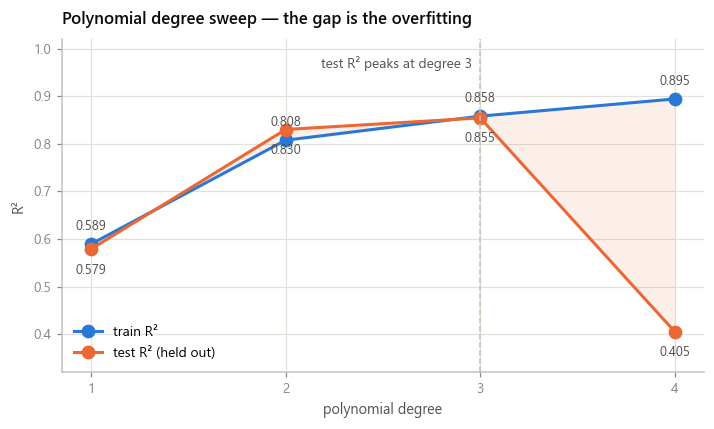

In [15]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.plot(demo["Degree"], demo["Train R²"], marker="o", color=SERIES[0],
        label="train R²")
ax.plot(demo["Degree"], demo["Test R²"], marker="o", color=SERIES[1],
        label="test R² (held out)")

ax.fill_between(demo["Degree"], demo["Test R²"], demo["Train R²"],
                color=SERIES[1], alpha=0.10)

for _, row in demo.iterrows():
    ax.annotate(f"{row['Train R²']:.3f}", (row["Degree"], row["Train R²"]),
                textcoords="offset points", xytext=(0, 9), ha="center",
                fontsize=8.5, color=INK_SECONDARY)
    ax.annotate(f"{row['Test R²']:.3f}", (row["Degree"], row["Test R²"]),
                textcoords="offset points", xytext=(0, -16), ha="center",
                fontsize=8.5, color=INK_SECONDARY)

peak = demo.loc[demo["Test R²"].idxmax()]
ax.axvline(peak["Degree"], color="#c3c2b7", linestyle="--", linewidth=1)
# Horizontal, above the lines: a rotated label here crossed the data, and the
# widening gap is the thing the reader should be looking at.
ax.annotate(f"test R² peaks at degree {int(peak['Degree'])}",
            (peak["Degree"] - 0.04, 0.985), fontsize=9, color=INK_SECONDARY,
            ha="right", va="top")

ax.set_title("Polynomial degree sweep — the gap is the overfitting")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("R²")
ax.set_xticks(demo["Degree"])
# Headroom below 0.405 so the degree-4 label does not land on the axis.
ax.set_ylim(0.32, 1.02)
ax.legend(loc="lower left")     # the only quadrant with no marks in it
despine(ax)
plt.tight_layout()
plt.show()

In [16]:
d3 = demo[demo.Degree == 3].iloc[0]
d4 = demo[demo.Degree == 4].iloc[0]

print("=" * 76)
print("DEGREE 3 vs DEGREE 4 — train and test side by side")
print("=" * 76)
print(f"{'':<12}{'terms':>8}{'train R²':>12}{'test R²':>11}{'gap':>10}"
      f"{'test RMSE':>14}")
for label, row in [("degree 3", d3), ("degree 4", d4)]:
    print(f"{label:<12}{int(row['Terms']):>8}{row['Train R²']:>12.4f}"
          f"{row['Test R²']:>11.4f}{row['Gap (train - test)']:>10.4f}"
          f"{row['Test RMSE']:>14,.0f}")
print("=" * 76)
print()
print(f"Going from degree 3 to degree 4:")
print(f"  terms          {int(d3['Terms'])} -> {int(d4['Terms'])} "
      f"({d4['Terms'] / d3['Terms']:.1f}x more parameters)")
print(f"  train R²       {d3['Train R²']:.4f} -> {d4['Train R²']:.4f}  "
      f"({d4['Train R²'] - d3['Train R²']:+.4f})  <- looks better")
print(f"  test R²        {d3['Test R²']:.4f} -> {d4['Test R²']:.4f}  "
      f"({d4['Test R²'] - d3['Test R²']:+.4f})  <- is worse")
print(f"  train-test gap {d3['Gap (train - test)']:.4f} -> "
      f"{d4['Gap (train - test)']:.4f}  "
      f"({d4['Gap (train - test)'] / max(d3['Gap (train - test)'], 1e-9):.1f}x wider)")
print(f"  test RMSE      ₹{d3['Test RMSE']:,.0f} -> ₹{d4['Test RMSE']:,.0f}  "
      f"(₹{d4['Test RMSE'] - d3['Test RMSE']:+,.0f} per listing)")

DEGREE 3 vs DEGREE 4 — train and test side by side
               terms    train R²    test R²       gap     test RMSE
degree 3          83      0.8584     0.8547    0.0037       179,287
degree 4         209      0.8946     0.4051    0.4895       362,803

Going from degree 3 to degree 4:
  terms          83 -> 209 (2.5x more parameters)
  train R²       0.8584 -> 0.8946  (+0.0362)  <- looks better
  test R²        0.8547 -> 0.4051  (-0.4496)  <- is worse
  train-test gap 0.0037 -> 0.4895  (133.7x wider)
  test RMSE      ₹179,287 -> ₹362,803  (₹+183,516 per listing)


### What the demonstration shows

**Degree 4 fits the training data better and the world worse.** Train R² goes *up*, so
a practitioner watching only training performance would read degree 4 as the better
model and ship it. Test R² goes *down*, and test RMSE goes up by tens of thousands of
rupees on every listing.

The mechanism is the term count. Degree 4 over six features is 209 terms against 83 at
degree 3 — two and a half times the parameters, all fitted on the same fixed number of
training rows. The extra capacity does not find more signal, because there was no more
signal to find; it fits the noise particular to those rows, and that noise does not
recur in the test set.

**This is why the train/test split exists**, and why the split must happen before any
statistic is computed from the data — which is the property the preprocessing template
enforces structurally rather than by convention. The decision tree in section 6.1 shows
the same phenomenon without being asked to: train R² 1.0000, and a test R² well below
it.

The practical rule the sweep illustrates: **a widening gap between train and test
performance is the signal to stop adding capacity**, and the peak of the *test* curve —
never the train curve — is where the useful model is.

## 7. Summary

In [17]:
print("=" * 92)
print("REGRESSION FAMILY COMPARISON — FINAL RESULTS (held-out test set)")
print("=" * 92)
print(f"dataset   : {DATA_PATH.name} — {len(cars):,} rows, "
      f"{split.n_duplicates_dropped:,} exact duplicates dropped before splitting")
print(f"split     : {len(X_train):,} train / {len(X_test):,} test, "
      f"random_state={RANDOM_STATE}")
print(f"target    : {CAR_TARGET} (native ₹, not log-transformed)")
print(f"features  : {X_train.shape[1]} columns after impute → encode → scale")
print()
print(f"{'Model':<28}{'Test R²':>10}{'Test RMSE':>15}{'Train R²':>11}{'gap':>9}")
print("-" * 92)
for _, row in table.iterrows():
    print(f"{row['Model']:<28}{row['Test R²']:>10.4f}"
          f"{row['Test RMSE (₹)']:>15,.0f}{row['Train R²']:>11.4f}"
          f"{row['R² gap']:>9.4f}")
print("-" * 92)
print()
print(f"overfitting demo: degree 3 gap {d3['Gap (train - test)']:.4f}  ->  "
      f"degree 4 gap {d4['Gap (train - test)']:.4f}")
print("=" * 92)

REGRESSION FAMILY COMPARISON — FINAL RESULTS (held-out test set)
dataset   : car_details_v3.csv — 8,128 rows, 1,221 exact duplicates dropped before splitting
split     : 5,525 train / 1,382 test, random_state=42
target    : selling_price (native ₹, not log-transformed)
features  : 33 columns after impute → encode → scale

Model                          Test R²      Test RMSE   Train R²      gap
--------------------------------------------------------------------------------------------
Random forest (200 trees)       0.9274        126,770     0.9858   0.0584
Polynomial (degree 3)           0.8942        152,998     0.9136   0.0194
SVR (RBF kernel)                0.8788        163,774     0.9805   0.1017
Decision tree                   0.8106        204,689     0.9992   0.1886
Multiple linear                 0.7131        251,967     0.7297   0.0167
Simple linear (1 feature)       0.4115        360,829     0.4864   0.0749
-----------------------------------------------------------------

### Caveats

- **One fixed 80/20 split.** Every number carries sampling noise that a point estimate
  hides; repeated k-fold cross-validation would give intervals instead.
- **No hyperparameter tuning.** Tree depth, forest size, SVR `C` and `gamma` are all
  at their stated defaults. The comparison is between *families at default settings*,
  which is the brief's question, not between each family's best achievable result.
- **RMSE is dominated by the expensive listings** (section 3), and the residual plot in
  6.3 shows systematic under-prediction above ~₹15 lakh.
- **Duplicate rows were exact-match only.** Two listings of the same car differing by
  one kilometre survive as distinct rows.
- **The `name` → `make` reduction discards trim information**, partly recoverable from
  `engine` and `max_power` but not entirely.